XGBoost Accuracy: 0.9


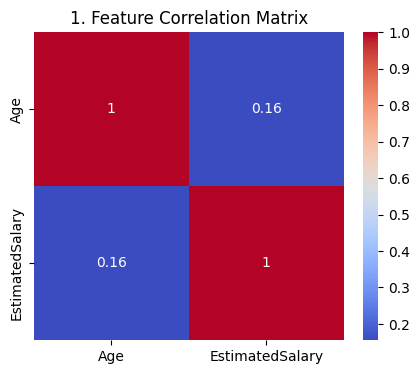

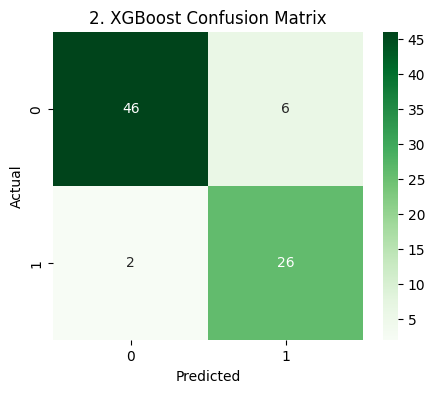

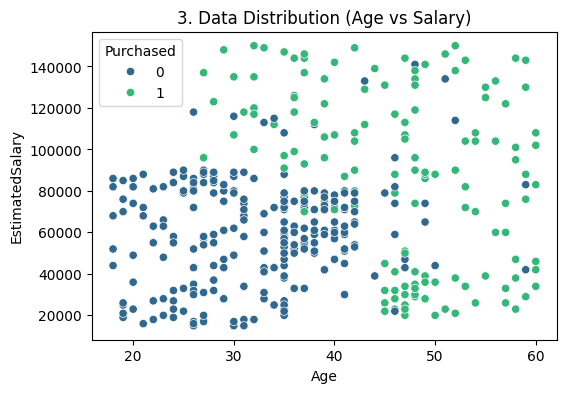

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier

df = pd.read_csv("https://raw.githubusercontent.com/shivang98/Social-Network-ads-Boost/master/Social_Network_Ads.csv")

X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, predictions)}")

plt.figure(figsize=(5, 4))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('1. Feature Correlation Matrix')
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, cmap='Greens', fmt='d')
plt.title('2. XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', palette='viridis')
plt.title('3. Data Distribution (Age vs Salary)')
plt.show()